<a href="https://colab.research.google.com/github/ViC3nte1/Pengolahan_Citra/blob/main/Jobsheet_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Praktikum 1 Segmentasi Menggunakan Thresholding Global dan Otsu

Dalam praktikum 1 ini akan menerapkan metode segmentasi berbasis thresholding pada citra grayscale dan akan membandingkan nilai thresholding dengan nilai ambang manual (global) dan nilai ambang otomatis yang ditentukan oleh Otsu

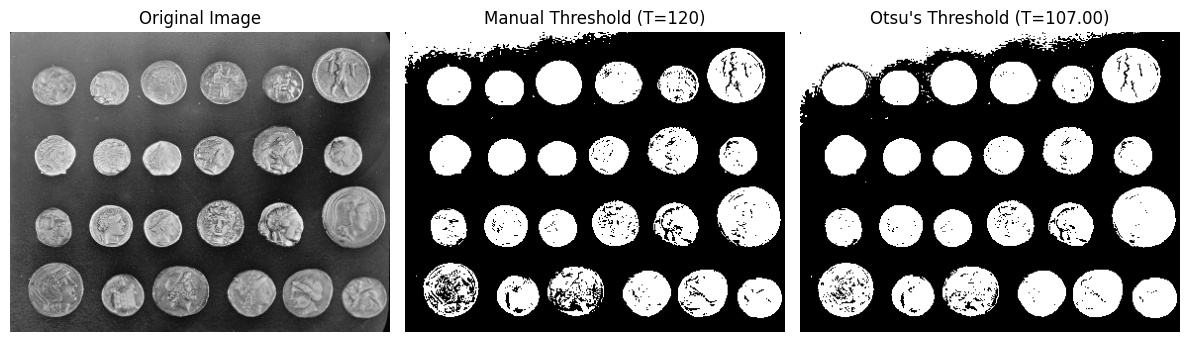

Nilai threshold Otsu yang ditemukan: 107


In [27]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

image_coins = data.coins()

thresh_manual = 120
binary_manual = image_coins > thresh_manual

thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

Hasil dari praktikum di atas menunjukkan bahwa hasil dari metode Otsu dapat memisahkan objek (koin) dari latar belakang dengan lebih baik dari metode Manual. Namun jika metode Manual menaikkan sedikit nilai Thresholdnya maka akan menghasilkan gambar yang lebih baik dari Otsu yaitu dari 100 (sesuai praktikum) menjadi 115 - 120

##Praktikum 2 Segmentasi Menggunakan Region Growing

Pada praktikum ini akan mendemonstrasikan konsep dasar region drawing dengan menggunakan flood dari skimage.segmentation

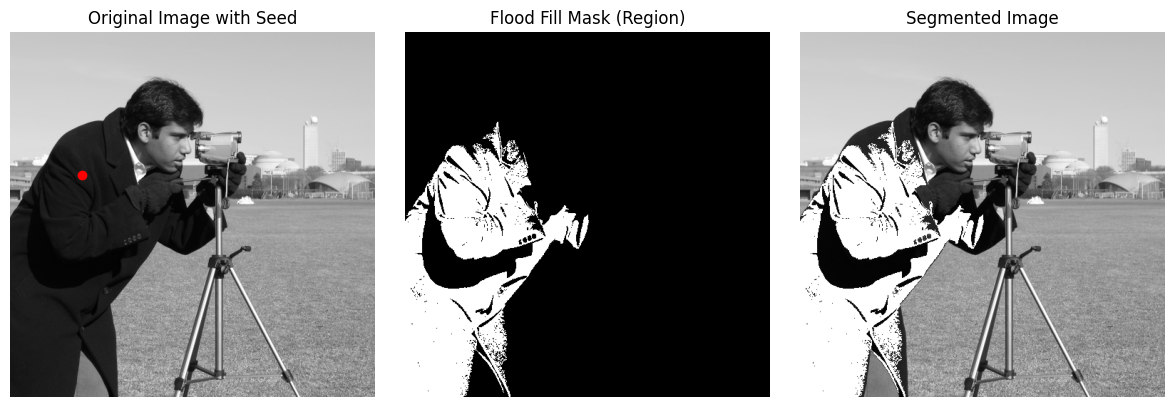

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

image_camera = data.camera()

seed_point = (200, 100)

flood_mask = segmentation.flood(image_camera, seed_point, tolerance=9)

segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Pada praktikum tersebut, nilai seed akan digunakan untuk memilih area atau titik dan akan diambil nilai pikselnya untuk diproses. Metode ini akan memilih bagian mana saja yang memiliki nilai piksel yang sama atau mirip sesuai dengan nilai tolerance yang sudah diberikan. Semisal saya ubah seed menjadi (200, 100) dari (100, 150) dan tolerance menjadi 9 dari (10) karena saya ingin memilih pakaian yang digunakan oleh kameramen tersebut

##Praktikum 3 Segmentasi Citra Berwarna Menggunakan K-Means Clustering

Pada praktikum ini akan menerapkan K-Means clustering untuk mensegmentasi citra berwarna bersasarkan nilai warna piksel

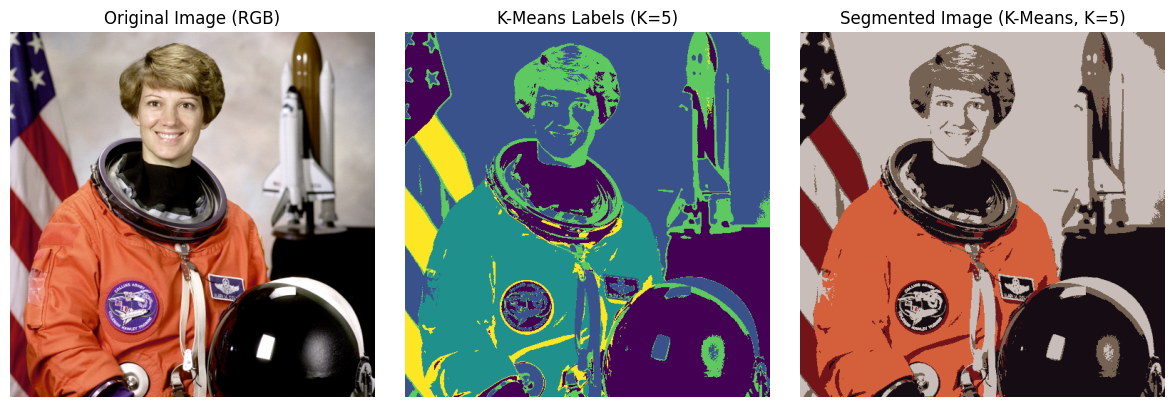

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

image_astro = data.astronaut()

image_astro_float = image_astro.astype(float) / 255.0

image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_labels = pixel_labels.reshape(rows, cols)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
  cluster_pixels = (pixel_labels == k)
  mask_k = cluster_pixels.reshape(rows, cols)
  segmented_image_kmeans[mask_k] = centers_lab[k]

segmented_image_rgb = lab2rgb(segmented_image_kmeans)

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title("Original Image (RGB)")
ax[0].axis("off")

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f"K-Means Labels (K={n_clusters})")
ax[1].axis("off")

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f"Segmented Image (K-Means, K={n_clusters})")
ax[2].axis("off")

plt.tight_layout()
plt.show()

Setelah saya ubah nilai dari kluster, maka akan menghasilkan gambar yang kurang jelas pada hasil ke-2 meskipun untuk hasil ke-3 masih dapat terlihat, semisal pada kluster = 5 hasil ke-2 kurang jelas namun hasil ke-3 sedikit lebih baik dari kluster = 4 (sesuai praktikum), sedangkan pada kluster = 3 memiliki hasil ke-2 dan ke-3 kurang jelas. Jadi dapat disimpulkan bahwa jumlah kluster sangat berpengaruh pada hasil metode ini.

Ruang warna lab sangat membantu dalam pengolahan citra berbasis KMeans karena memberikan representasi warna yang lebih sesuai dengan persepsi manusia

##Praktikum 4 Segmentasi Berbasis Tepi Menggunakan Watershed

Pada praktikum ini akan menggunakan Watershed untuk memisahkan objek yang saling bersentuhan. Algoritma ini memperlakukan citra seperti relief topografi dan mengisi cekungan dengan air

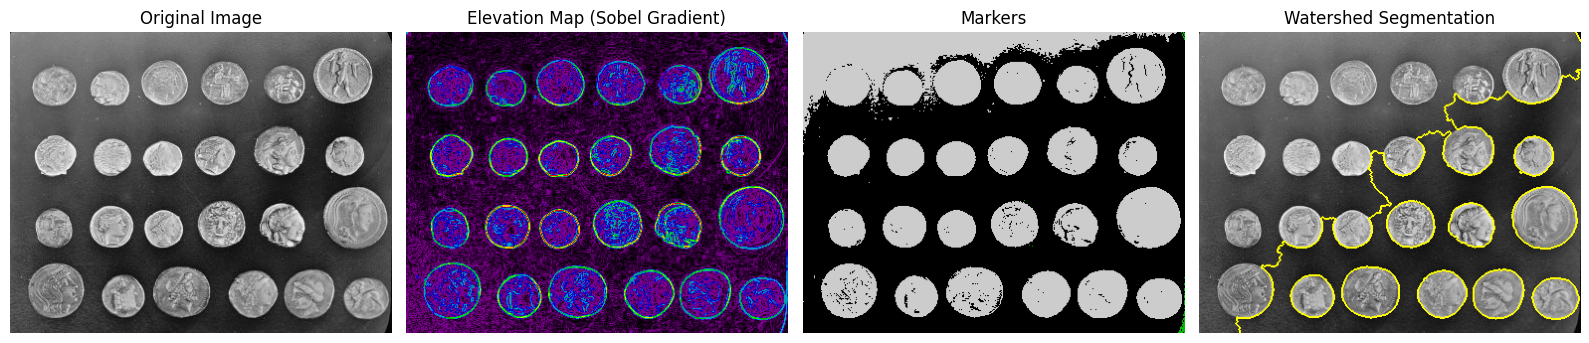

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

image_coins = data.coins()

elevation_map = filters.sobel(image_coins)

markers = np.zeros_like(image_coins)
markers[image_coins < 10] = 1
markers[image_coins > 100] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmented_colored 	= 	segmentation.mark_boundaries(image_coins, segmentation_watershed)

fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()


Ya pemilihan marker sangat berpengaruh pada hasil akhir. Jika nilai marker tidak tepat akan menghasilkan gambar seperti di atas, watershed tidak dapat mensegmentasi citra dengan baik. Setelah saya coba untuk mengganti nilai (< 30) menjadi (< 50) untuk marker 1 dan (> 150) menjadi (> 250) untuk marker 2 maka citra yang dihasilkan akan mensegmentasi 1 koin saja. Jika saya ubah menjadi (< 10) dan (>100) maka hasilnya akan mensegmentasi beberapa koin saja.

##Praktikum 5 Perbandingan Visual Hasil Segmentasi

Pada praktikum ini akan membandingkan hasil dari beberapa metode segmentasi pada citra yang sama untuk melihat perbedaan, kelebihan, dan kekurangan masing-masing secara visual

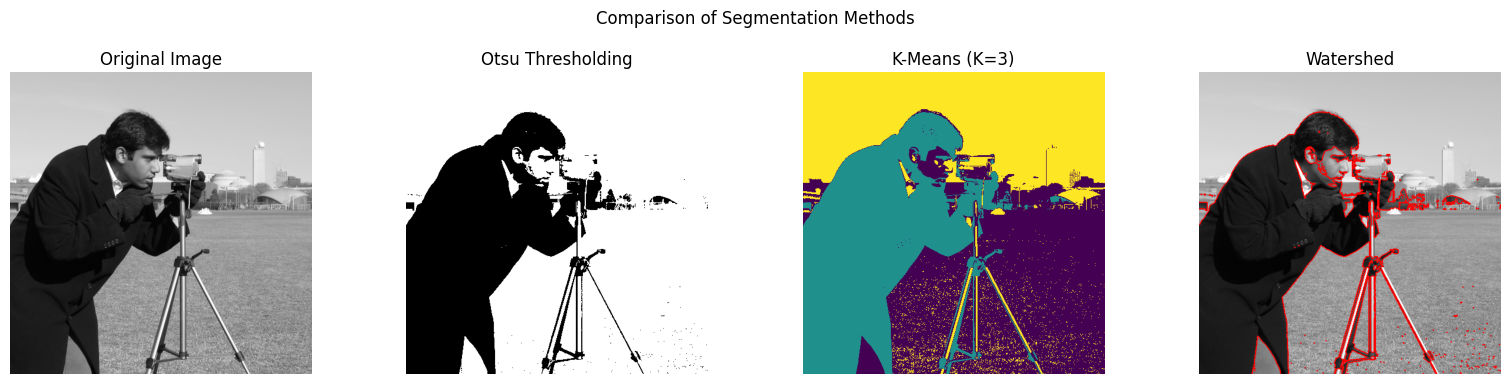

In [53]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

image = data.camera()
image_float = img_as_float(image)

thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1,0,0))

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Jika dilakukan sesuai dengan praktikum, maka KMeans mendapatkan hasil yang paling bagus karena dapat memisahkan langit, dataran, dan kameramen. Sedangkan untuk kedua metode yaitu Thresholding dan Watershed hanya membedakan beberapa bagian saja seperti Thresholding yang hanya mendapat kameramen dan kamera dan Watershed hanya dapat kameramen, kamera, dan sedikit bangunan.

Berdasarkan hasil dari visualisasi tersbut, masing-masing metode memiliki kelebihan dan kekurangan sebagai berikut:

Kelebihan Thresholding:
1. Dapat memisahkan gambar dengan jelas jika kontras tinggi

Kelemahan Thresholding:
1. Hanya membagi 2 bagian, misal latar belakang dan objek
2. Jika kontras rendah maka hasil akan buruk

Kelebihan K-Means:
1. Dapat membagi citra yang memiliki banyak objek
2. Hasil segmentasi fleksibel sesuai jumlah kluster

Kelemahan K-Means:
1. Sensitif terhadap jumlah kluster
2. Segmentasi berpengaruh jika objek memiliki bentuk kompleks atau overlap

Kelebihan Watershed:
1. Jika marker tepat maka hasil segmentasi akan bagus
2. Dapat mmembedakan objek yang tumpang tindih

Kelemahan Watershed:
1. Jika marker tidak tepat dapat menyebabkan over-segmentasi
2. Sangat sensitif terhadap nilai marker